# Advanced Analytics

This notebook performs advanced quantitative analysis on the mutual fund dataset.

The following analyses are included:

- Historical Value at Risk (VaR) & Conditional VaR (CVaR)
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation System
- Sector Concentration using HHI
- Advanced Insights

In [3]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

In [4]:
report_dir = Path("../reports")

report_dir.mkdir(
    parents=True,
    exist_ok=True
)

In [5]:
nav = pd.read_csv(
    "../data/processed/clean_nav_history.csv"
)

performance = pd.read_csv(
    "../data/processed/performance_metrics.csv"
)

investor = pd.read_csv(
    "../data/processed/clean_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [6]:
nav["date"] = pd.to_datetime(nav["date"])

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

holdings["portfolio_date"] = pd.to_datetime(
    holdings["portfolio_date"]
)

In [7]:
print(nav.head())

print(performance.head())

print(investor.head())

print(holdings.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639
   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct        

# Historical Value at Risk (VaR) and Conditional VaR (CVaR)

Historical VaR estimates the maximum expected loss at the 95% confidence level.

CVaR represents the average loss beyond the VaR threshold.

In [8]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [9]:
returns = nav.dropna(
    subset=["daily_return"]
)

In [10]:
var_results = []

for fund in returns["amfi_code"].unique():

    temp = returns[
        returns["amfi_code"] == fund
    ]

    var95 = np.percentile(
        temp["daily_return"],
        5
    )

    cvar95 = temp.loc[
        temp["daily_return"] <= var95,
        "daily_return"
    ].mean()

    var_results.append({

        "amfi_code": fund,

        "VaR_95": var95,

        "CVaR_95": cvar95

    })

var_report = pd.DataFrame(
    var_results
)

In [11]:
var_report = var_report.merge(

    performance[
        ["amfi_code", "scheme_name"]
    ],

    on="amfi_code",

    how="left"

)

In [12]:
var_report = var_report.sort_values(

    "VaR_95"

)

var_report.head()

,amfi_code,VaR_95,CVaR_95,scheme_name
22,119599,-0.026859,-0.032384,SBI Small Cap Fund - Direct Plan - Growth
17,119095,-0.026188,-0.031667,Axis Small Cap Fund - Regular - Growth
4,101207,-0.026021,-0.032459,ABSL Small Cap Fund - Regular - Growth
11,118634,-0.025438,-0.032304,Nippon India Small Cap Fund - Regular - Growth
21,119598,-0.024507,-0.030595,SBI Small Cap Fund - Regular Plan - Growth


In [13]:
var_report.to_csv(

    report_dir / "var_cvar_report.csv",

    index=False

)

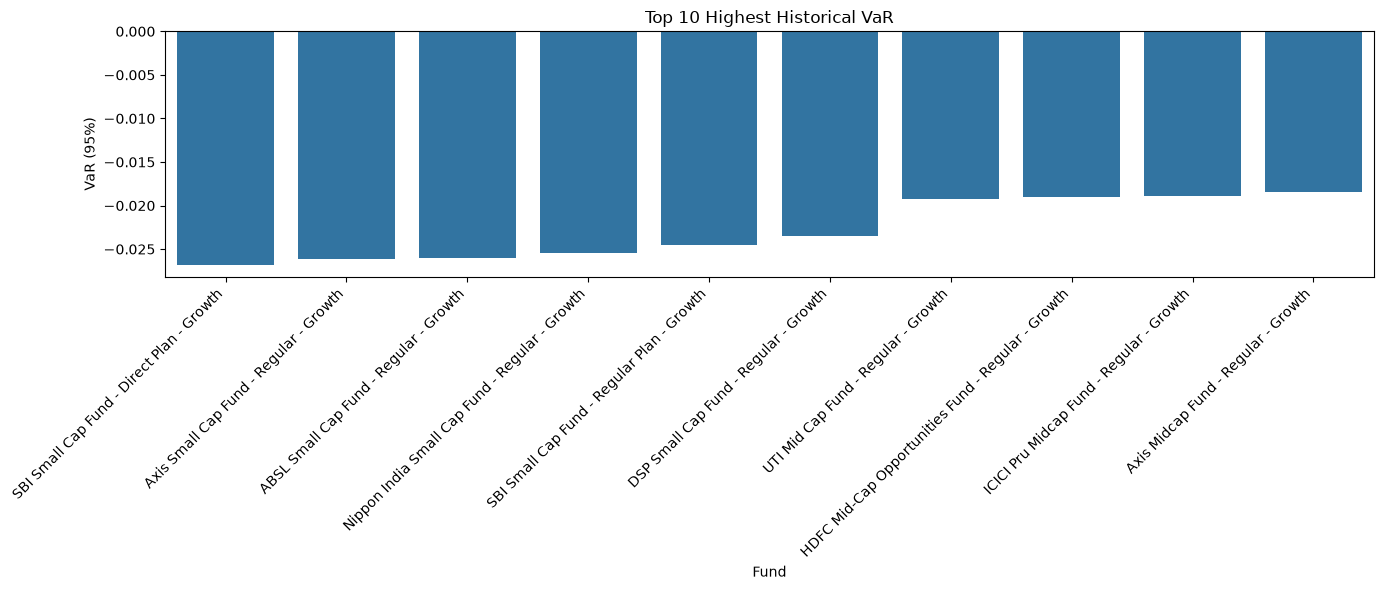

In [14]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=var_report.head(10),

    x="scheme_name",

    y="VaR_95"

)

plt.xticks(

    rotation=45,

    ha="right"

)

plt.title(

    "Top 10 Highest Historical VaR"

)

plt.xlabel(

    "Fund"

)

plt.ylabel(

    "VaR (95%)"

)

plt.tight_layout()

plt.savefig(

    report_dir / "historical_var.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

# Rolling 90-Day Sharpe Ratio

The rolling Sharpe Ratio measures the risk-adjusted return over a moving 90-day window.

The analysis is performed for the top five funds based on Fund Score.

In [15]:
top5 = (
    performance
    .sort_values(
        "Fund_Score",
        ascending=False
    )
    .head(5)
)

top5_codes = top5["amfi_code"].tolist()

top5_names = dict(
    zip(
        top5["amfi_code"],
        top5["scheme_name"]
    )
)

top5

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,Beta,Maximum_Drawdown,Worst_Drawdown_Date,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,Tracking_Error
32,102886,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap,Regular,16.30,15.61,15.86,14.49,1.12,...,-0.042125,-0.280011,2026-04-27,37.0,36.0,40.0,24.5,35.0,35.275,0.225608
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,...,-0.058268,-0.247344,2022-09-15,35.0,35.0,39.0,32.0,34.0,35.250,0.199284
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,...,-0.066951,-0.516778,2026-05-11,40.0,33.0,37.0,17.0,39.0,34.100,0.285781
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,-0.065289,-0.354469,2026-05-11,39.0,28.0,27.0,28.5,38.0,32.175,0.292117
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,...,0.009731,-0.144016,2025-02-07,36.0,31.0,30.0,39.5,15.0,31.975,0.189082


In [16]:
rolling_nav = nav[
    nav["amfi_code"].isin(top5_codes)
].copy()

rolling_nav = rolling_nav.sort_values(
    ["amfi_code", "date"]
)

In [17]:
rolling_results = []

for fund in top5_codes:

    temp = rolling_nav[
        rolling_nav["amfi_code"] == fund
    ].copy()

    temp["rolling_mean"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
    )

    temp["rolling_std"] = (
        temp["daily_return"]
        .rolling(90)
        .std()
    )

    temp["rolling_sharpe"] = (
        temp["rolling_mean"]
        /
        temp["rolling_std"]
    ) * np.sqrt(252)

    rolling_results.append(temp)

rolling_sharpe = pd.concat(
    rolling_results,
    ignore_index=True
)

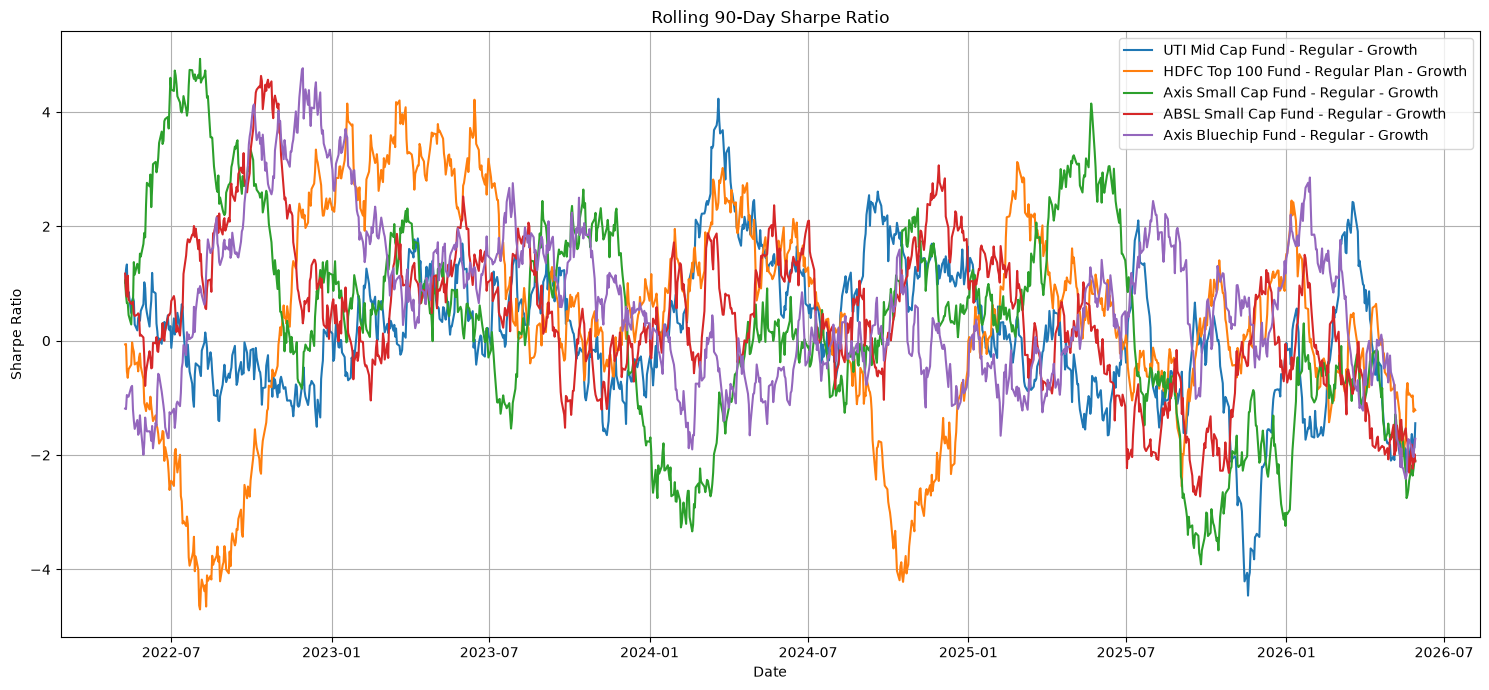

In [18]:
plt.figure(figsize=(15,7))

for fund in top5_codes:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    plt.plot(

        temp["date"],

        temp["rolling_sharpe"],

        label=top5_names[fund]

    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sharpe Ratio"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(

    report_dir / "rolling_sharpe_chart.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [19]:
rolling_sharpe.to_csv(

    report_dir / "rolling_sharpe.csv",

    index=False

)

### Observation

The rolling Sharpe Ratio fluctuates over time as fund returns and volatility change. Funds with consistently higher rolling Sharpe values demonstrate superior risk-adjusted performance over the analysis period.

# Investor Cohort Analysis

Investor cohort analysis groups investors based on the year of their first SIP investment.

The analysis includes:

- Cohort Year
- Number of Investors
- Average SIP Amount
- Total SIP Investment

In [20]:
sip = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified


In [21]:
first_txn = (
    sip.groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-09-13,2024


In [22]:
sip = sip.merge(

    first_txn[
        ["investor_id", "cohort_year"]
    ],

    on="investor_id",

    how="left"

)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
2,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
3,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
4,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [23]:
cohort = (

    sip.groupby("cohort_year")

    .agg(

        Investors=(
            "investor_id",
            "nunique"
        ),

        Avg_SIP_Amount=(
            "amount_inr",
            "mean"
        ),

        Total_Investment=(
            "amount_inr",
            "sum"
        )

    )

    .reset_index()

)

cohort

,cohort_year,Investors,Avg_SIP_Amount,Total_Investment
0,2024,4456,10986.861803,212189262
1,2025,306,12516.697270,5044229


In [24]:
cohort.to_csv(

    report_dir / "cohort_analysis.csv",

    index=False

)

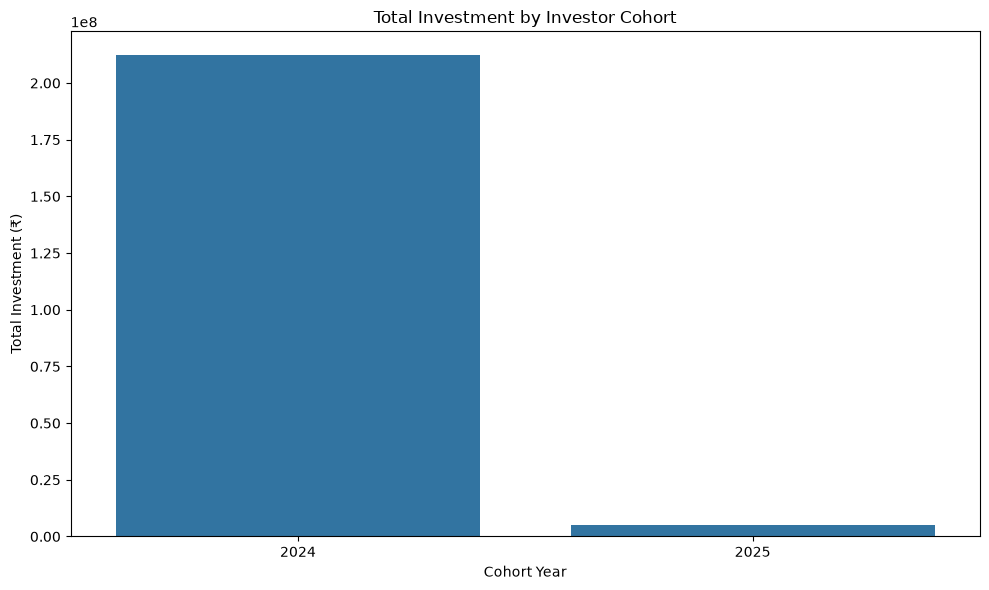

In [25]:
plt.figure(figsize=(10,6))

sns.barplot(

    data=cohort,

    x="cohort_year",

    y="Total_Investment"

)

plt.title(

    "Total Investment by Investor Cohort"

)

plt.xlabel(

    "Cohort Year"

)

plt.ylabel(

    "Total Investment (₹)"

)

plt.tight_layout()

plt.savefig(

    report_dir / "cohort_analysis.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

### Observation

The cohort analysis shows how investment behaviour changes across investor generations.

Higher average SIP amounts indicate stronger investment capacity, while total investment reflects the overall contribution of each cohort.

# SIP Continuity Analysis

This analysis identifies investors who have maintained regular SIP investments.

Investors with six or more SIP transactions are analysed.

Average gap between consecutive SIP dates is computed.

Investors with an average gap greater than 35 days are classified as **At Risk**.

In [26]:
sip = investor[
    investor["transaction_type"] == "SIP"
].copy()

sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified


In [27]:
sip_counts = (
    sip.groupby("investor_id")
       .size()
       .reset_index(name="sip_count")
)

eligible = sip_counts[
    sip_counts["sip_count"] >= 6
]["investor_id"]

sip = sip[
    sip["investor_id"].isin(eligible)
]

In [28]:
sip["gap_days"] = (

    sip.groupby("investor_id")["transaction_date"]

       .diff()

       .dt.days

)

In [29]:
continuity = (

    sip.groupby("investor_id")

    .agg(

        Average_Gap_Days=("gap_days", "mean"),

        Total_SIPs=("transaction_date", "count"),

        Total_Investment=("amount_inr", "sum")

    )

    .reset_index()

)

In [30]:
continuity["Status"] = np.where(

    continuity["Average_Gap_Days"] > 35,

    "At Risk",

    "Regular"

)

continuity.head()

,investor_id,Average_Gap_Days,Total_SIPs,Total_Investment,Status
0,INV000004,85.400000,6,48256,At Risk
1,INV000008,70.400000,6,72853,At Risk
2,INV000010,64.800000,6,32183,At Risk
3,INV000011,40.166667,7,93920,At Risk
4,INV000012,57.000000,8,40139,At Risk


In [31]:
continuity.to_csv(

    report_dir / "sip_continuity.csv",

    index=False

)

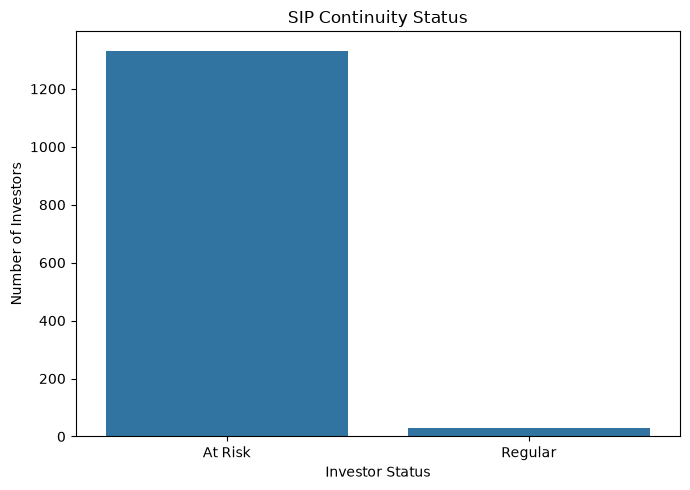

In [32]:
plt.figure(figsize=(7,5))

sns.countplot(

    data=continuity,

    x="Status"

)

plt.title(

    "SIP Continuity Status"

)

plt.xlabel(

    "Investor Status"

)

plt.ylabel(

    "Number of Investors"

)

plt.tight_layout()

plt.savefig(

    report_dir / "sip_continuity.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

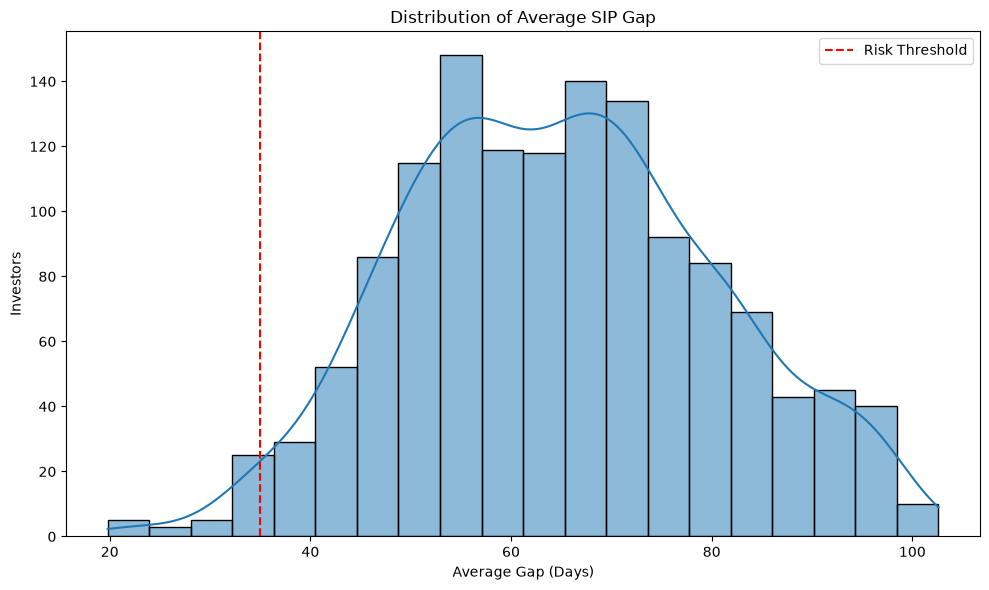

In [33]:
plt.figure(figsize=(10,6))

sns.histplot(

    continuity["Average_Gap_Days"],

    bins=20,

    kde=True

)

plt.axvline(

    35,

    color="red",

    linestyle="--",

    label="Risk Threshold"

)

plt.title(

    "Distribution of Average SIP Gap"

)

plt.xlabel(

    "Average Gap (Days)"

)

plt.ylabel(

    "Investors"

)

plt.legend()

plt.tight_layout()

plt.savefig(

    report_dir / "sip_gap_distribution.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

### Observation

Most investors maintain consistent SIP investments.

Investors with an average gap exceeding 35 days are classified as **At Risk** and may require engagement to improve investment continuity.

# Simple Mutual Fund Recommendation System

This recommendation system suggests the top three mutual funds based on the investor's risk appetite.

Recommendations are ranked using the Sharpe Ratio within each risk category.

In [41]:
print("Available Risk Grades:\n")

print(performance["risk_grade"].value_counts())

Available Risk Grades:

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64


In [47]:
print("\nAvailable Risk Grades:")

print(performance["risk_grade"].unique())

risk = input(
    "\nEnter Risk Appetite exactly as shown above: "
)


Available Risk Grades:
<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str


In [48]:
risk = risk.strip().lower()

recommend = (
    performance[
        performance["risk_grade"]
        .str.strip()
        .str.lower()
        == risk
    ]
    .sort_values(
        "Sharpe_Ratio",
        ascending=False
    )
    .head(3)
)

display(recommend)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,Beta,Maximum_Drawdown,Worst_Drawdown_Date,Return_Rank,Sharpe_Rank,Alpha_Rank,Expense_Rank,Drawdown_Rank,Fund_Score,Tracking_Error
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,-0.000444,-0.000977,2025-10-20,29.0,23.0,31.0,7.0,1.0,21.80,0.129044
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra MF,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,...,-0.000401,-0.001163,2024-04-30,30.0,34.0,32.0,3.0,2.0,24.55,0.129046
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,-0.006414,-0.043287,2025-04-01,32.0,37.0,34.0,9.0,5.0,27.50,0.135646


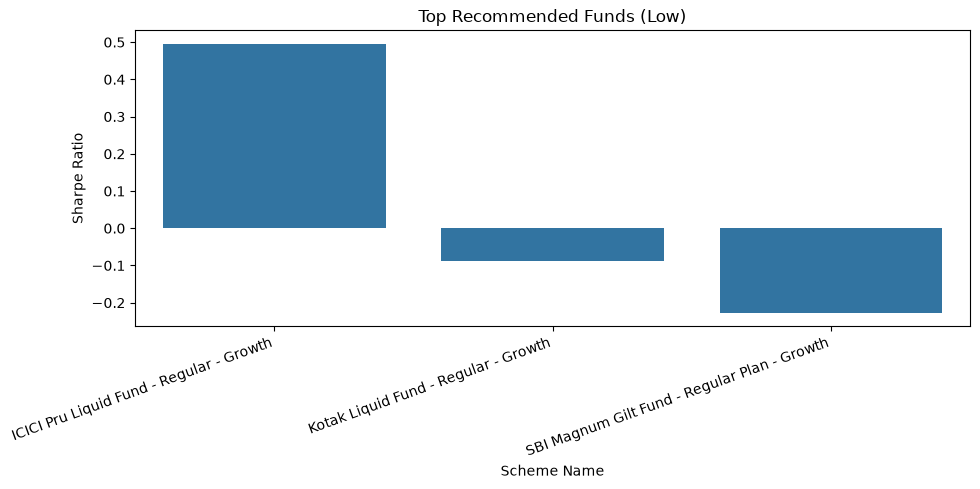

In [49]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=recommend,
    x="scheme_name",
    y="Sharpe_Ratio"
)

plt.xticks(rotation=20, ha="right")

plt.title(f"Top Recommended Funds ({risk.title()})")

plt.xlabel("Scheme Name")

plt.ylabel("Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    report_dir / "fund_recommendations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [50]:
recommend.to_csv(
    report_dir / "fund_recommendations.csv",
    index=False
)

In [51]:
recommender_code = '''
import pandas as pd

performance = pd.read_csv("performance_metrics.csv")

print("\\nAvailable Risk Grades:")

print(performance["risk_grade"].unique())

risk = input("\\nEnter Risk Appetite: ")

recommend = (

    performance[
        performance["risk_grade"]
        .str.lower()
        ==
        risk.lower()
    ]

    .sort_values(
        "Sharpe_Ratio",
        ascending=False
    )

    .head(3)

)

print(

recommend[
[
"scheme_name",
"fund_house",
"category",
"risk_grade",
"Sharpe_Ratio",
"Fund_Score"
]

)

'''

with open(

    report_dir / "recommender.py",

    "w"

) as file:

    file.write(
        recommender_code
    )

### Observation

The recommendation engine suggests the top three mutual funds based on the investor's selected risk appetite.

Funds are ranked according to their Sharpe Ratio, ensuring recommendations prioritize superior risk-adjusted performance.

# Sector Concentration Analysis using HHI

The Herfindahl-Hirschman Index (HHI) measures portfolio concentration.

HHI = Σ(weight²)

Higher HHI indicates a more concentrated portfolio.

Lower HHI indicates better diversification.

In [69]:
# Aggregate stock weights into sector weights

sector_weights = (
    holdings
    .groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

sector_weights.head()

,amfi_code,sector,weight_pct
0,100016,Automobile,14.84
1,100016,Banking,3.39
2,100016,Energy,6.09
3,100016,FMCG,11.68
4,100016,IT,25.90


In [70]:
# Calculate Sector HHI

hhi = (
    sector_weights
    .groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x / 100) ** 2).sum())
    .reset_index(name="HHI")
)

display(hhi.head())

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


In [54]:
hhi = hhi.merge(

    performance[

        [

            "amfi_code",

            "scheme_name",

            "fund_house",

            "category"

        ]

    ],

    on="amfi_code",

    how="left"

)

hhi.head()

,amfi_code,HHI,scheme_name,fund_house,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth,UTI Mutual Fund,Index


In [63]:
equity_categories = [
    "Large Cap",
    "Mid Cap",
    "Small Cap",
    "Flexi Cap",
    "Large & Mid Cap",
    "Value",
    "ELSS"
]

equity = hhi[
    hhi["category"].isin(equity_categories)
].copy()

print(f"Total Equity Funds: {len(equity)}")

display(equity.head())

Total Equity Funds: 32


,amfi_code,HHI,scheme_name,fund_house,category
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mutual Fund,Mid Cap
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth,Aditya Birla Sun Life MF,Large Cap
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth,UTI Mutual Fund,Mid Cap


In [64]:
equity = (
    equity
    .sort_values("HHI", ascending=False)
    .reset_index(drop=True)
)

print("Top 10 Most Concentrated Equity Funds")

display(
    equity[
        [
            "scheme_name",
            "fund_house",
            "category",
            "HHI"
        ]
    ].head(10)
)

Top 10 Most Concentrated Equity Funds


,scheme_name,fund_house,category,HHI
0,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,0.206448
1,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,0.200700
2,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,0.174751
3,Nippon India Large Cap Fund - Regular - Growth,Nippon India MF,Large Cap,0.168298
4,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset MF,Large & Mid Cap,0.167930
5,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,0.157570
6,ICICI Pru Value Discovery Fund - Regular - Growth,ICICI Prudential MF,Value,0.153794
7,HDFC Mid-Cap Opportunities Fund - Direct - Growth,HDFC Mutual Fund,Mid Cap,0.152414
8,Kotak Bluechip Fund - Regular - Growth,Kotak Mahindra MF,Large Cap,0.149680
9,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,ELSS,0.149396


In [65]:
equity.to_csv(

    report_dir / "sector_hhi.csv",

    index=False

)

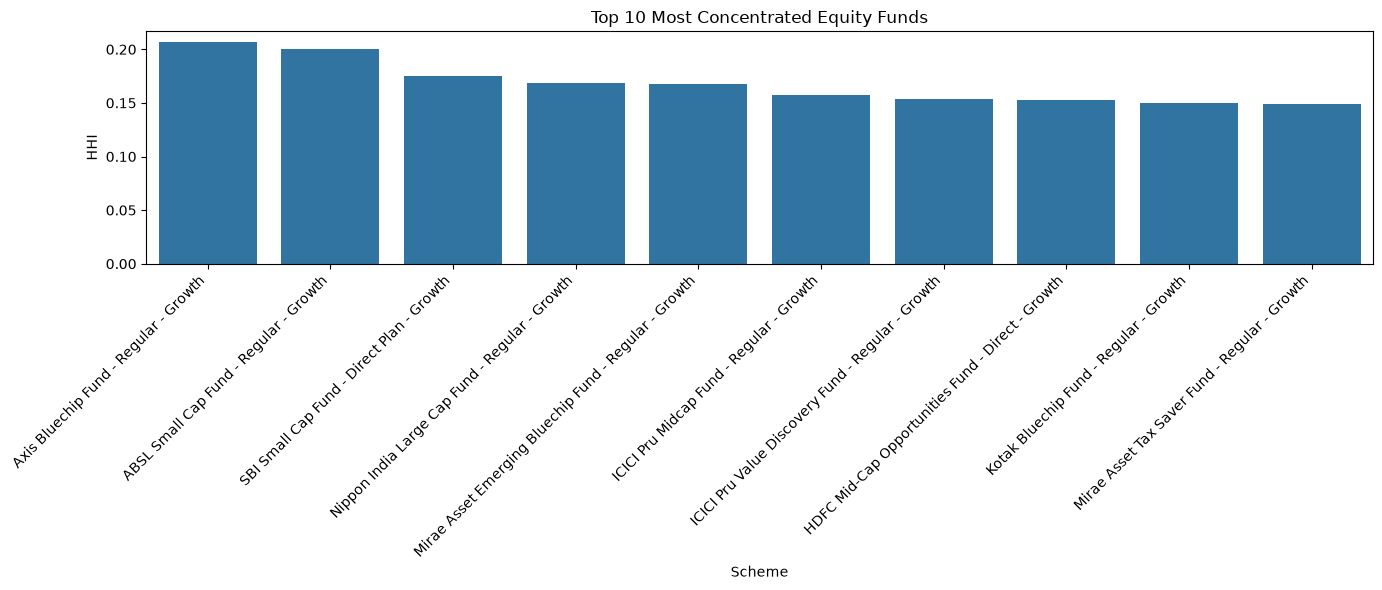

In [66]:
plt.figure(figsize=(14,6))

sns.barplot(

    data=equity.head(10),

    x="scheme_name",

    y="HHI"

)

plt.xticks(

    rotation=45,

    ha="right"

)

plt.title(

    "Top 10 Most Concentrated Equity Funds"

)

plt.xlabel(

    "Scheme"

)

plt.ylabel(

    "HHI"

)

plt.tight_layout()

plt.savefig(

    report_dir / "sector_hhi.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

### Observation

Funds with higher HHI values are more concentrated in a few sectors, while lower HHI values indicate better portfolio diversification.

# Advanced Insights

In [71]:
highest_var = var_report.loc[var_report["VaR_95"].idxmin()]

print("Highest Risk Fund")

display(highest_var)

Highest Risk Fund


amfi_code                                         119599
VaR_95                                         -0.026859
CVaR_95                                        -0.032384
scheme_name    SBI Small Cap Fund - Direct Plan - Growth
Name: 22, dtype: object

### Insight 1

The fund displayed above has the highest downside risk (lowest 95% VaR), indicating it is expected to experience the largest potential daily loss under adverse market conditions.

In [72]:
best_sharpe = performance.loc[
    performance["Sharpe_Ratio"].idxmax()
]

print("Highest Sharpe Ratio Fund")

display(
    best_sharpe[
        [
            "scheme_name",
            "Sharpe_Ratio",
            "Fund_Score"
        ]
    ]
)

Highest Sharpe Ratio Fund


scheme_name     Mirae Asset Large Cap Fund - Regular - Growth
Sharpe_Ratio                                         1.448291
Fund_Score                                                6.5
Name: 34, dtype: object

### Insight 2

The fund with the highest Sharpe Ratio achieved the strongest risk-adjusted performance, delivering higher returns relative to the level of risk undertaken.

In [73]:
largest = cohort.loc[
    cohort["Total_Investment"].idxmax()
]

print("Largest Investor Cohort")

display(largest)

Largest Investor Cohort


cohort_year         2.024000e+03
Investors           4.456000e+03
Avg_SIP_Amount      1.098686e+04
Total_Investment    2.121893e+08
Name: 0, dtype: float64

### Insight 3

The cohort with the highest total investment represents the strongest contributor to SIP investments during the analysis period.

In [74]:
summary = continuity["Status"].value_counts()

print(summary)

Status
At Risk    1332
Regular      30
Name: count, dtype: int64


### Insight 4

Most investors maintain regular SIP contributions, while investors classified as **At Risk** exhibit an average investment gap exceeding 35 days.

In [75]:
highest_hhi = equity.iloc[0]

print("Most Concentrated Portfolio")

display(
    highest_hhi[
        [
            "scheme_name",
            "category",
            "HHI"
        ]
    ]
)

Most Concentrated Portfolio


scheme_name    Axis Bluechip Fund - Regular - Growth
category                                   Large Cap
HHI                                         0.206448
Name: 0, dtype: object

### Insight 5

Funds with higher Sector HHI values allocate a larger proportion of assets to a limited number of sectors, whereas lower HHI values indicate more diversified portfolios.

In [76]:
from pathlib import Path

print("Generated Report Files:\n")

for file in sorted(report_dir.iterdir()):
    print(file.name)

Generated Report Files:

charts
cohort_analysis.csv
cohort_analysis.png
data_dictionary.md
fund_recommendations.csv
fund_recommendations.png
historical_var.png
recommender.py
rolling_sharpe.csv
rolling_sharpe_chart.png
sector_hhi.csv
sector_hhi.png
sip_continuity.csv
sip_continuity.png
sip_gap_distribution.png
var_cvar_report.csv


# Conclusion

This notebook performed advanced quantitative analysis on the mutual fund dataset by evaluating portfolio risk, investor behaviour, and fund performance.

Key analyses included Historical Value at Risk (VaR), Conditional Value at Risk (CVaR), Rolling 90-Day Sharpe Ratio, Investor Cohort Analysis, SIP Continuity Analysis, Fund Recommendation System, and Sector Concentration using the Herfindahl-Hirschman Index (HHI).

The results demonstrate how advanced analytics can be used to assess downside risk, identify high-performing funds, understand investor investment patterns, detect irregular SIP behaviour, and evaluate portfolio diversification. The recommendation system further illustrates how risk-adjusted performance metrics can support informed investment decisions.

Overall, this notebook complements the exploratory data analysis, performance analytics, and Power BI dashboard by providing deeper financial insights that can assist investors, fund managers, and financial analysts in making data-driven decisions.